# 035. 네이버 영화평 감성 분류

- 한글 형태소 분석기 Okt 사용 전처리  

- Keras Tokenizer, pad_sequences 함수 사용

In [1]:
!pip install -q KoNLPy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, LSTM

In [3]:
DATA_TRAIN_PATH = tf.keras.utils.get_file("ratings_train.txt",
                        "https://github.com/ironmanciti/NLP_lecture/raw/master/data/naver_movie/ratings_train.txt")
DATA_TEST_PATH = tf.keras.utils.get_file("ratings_test.txt",
                        "https://github.com/ironmanciti/NLP_lecture/raw/master/data/naver_movie/ratings_test.txt")

In [4]:
train_data = pd.read_csv(DATA_TRAIN_PATH, delimiter='\t')
print(train_data.shape)
train_data.head()

(150000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [5]:
test_data = pd.read_csv(DATA_TEST_PATH, delimiter='\t')
print(test_data.shape)
test_data.head()

(50000, 3)


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


### 훈련 시간을 감안하여 data size 축소

In [6]:
# 훈련 데이터에서 무작위로 50,000개의 샘플 추출
train_data = train_data.sample(n=50000, random_state=1)

# 테스트 데이터에서 무작위로 5,000개의 샘플 추출
test_data = test_data.sample(n=5000, random_state=1)

# 추출된 데이터셋의 크기 출력
print(train_data.shape)
print(test_data.shape)

(50000, 3)
(5000, 3)


**null value 제거**

In [7]:
train_data.isnull().sum(), test_data.isnull().sum()

(id          0
 document    3
 label       0
 dtype: int64,
 id          0
 document    0
 label       0
 dtype: int64)

In [8]:
train_data.dropna(inplace=True)

test_data.dropna(inplace=True)

In [9]:
train_data.isnull().sum(), test_data.isnull().sum()

(id          0
 document    0
 label       0
 dtype: int64,
 id          0
 document    0
 label       0
 dtype: int64)

### okt.morphs()

- 텍스트를 형태소 단위로 나눈다. 옵션으로는 norm과 stem이 있다
- stem은 각 단어에서 어간을 추출하는 기능

In [10]:
from konlpy.tag import Okt

# Okt 객체 생성
okt = Okt()

# 형태소 분석할 텍스트
test = "아버지가방에들어가신다"

# 형태소 분석 수행 (동사의 기본형 사용)
morphs = okt.morphs(test, stem=True)

# 분석된 형태소 출력
morphs

['아버지', '가방', '에', '들어가다']

## Text Data 전처리

**한글 문자가 아닌 것 모두 제거**

In [11]:
import re

def preprocessing(sentence, remove_stopwords=True):
    # 불용어 리스트
    # stop_words = set(['에', '은', '는', '이', '가', '그리고', '것', '들', '수', '등', '로', '을', '를', '만', '도', '아', '의', '그', '다'])
    stop_words = []

    # 문장 전처리
    sentence = re.sub('\\\\n', ' ', sentence)              # 개행문자 제거
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)  # 한글이 아닌 모든 문자 제거

    # Okt 형태소 분석기를 이용한 토큰화
    sentence = okt.morphs(sentence, stem=True)

    # 불용어 제거 옵션이 활성화된 경우 불용어 제거
    if remove_stopwords:
        sentence = [token for token in sentence if not token in stop_words]

    return sentence

In [12]:
import time

train_sentences = []
train_labels = []
test_sentences = []
test_labels = []

start = time.time()

# train 데이터 전처리
for i, (sent, label) in enumerate(zip(train_data['document'], train_data['label'])):
    if i % 10000 == 0:
        print(f"Train processed = {i}")       # 진행 상황 출력
    sent = preprocessing(sent)              # 문장 전처리
    if len(sent) > 0:        # 전처리된 문장이 비어있지 않은 경우
        train_sentences.append(sent)
        train_labels.append(label)

# test 데이터 전처리
for i, (sent, label) in enumerate(zip(test_data['document'], test_data['label'])):
    if i % 1000 == 0:
        print(f"Test processed = {i}")  # 진행 상황 출력
    sent = preprocessing(sent)        # 문장 전처리
    if len(sent) > 0:           # 전처리된 문장이 비어있지 않은 경우
        test_sentences.append(sent)
        test_labels.append(label)

# 전처리에 걸린 시간 출력
print(time.time() - start)

Train processed = 0
Train processed = 10000
Train processed = 20000
Train processed = 30000
Train processed = 40000
Test processed = 0
Test processed = 1000
Test processed = 2000
Test processed = 3000
Test processed = 4000
149.9656276702881


## train_labels, test_labels  list를 numpy array 로 변환

In [13]:
# 훈련 레이블을 NumPy 배열로 변환
train_labels = np.array(train_labels)

# 테스트 레이블을 NumPy 배열로 변환
test_labels = np.array(test_labels)

print(train_labels.shape)
print(test_labels.shape)

(49571,)
(4951,)


원래의 문장과 Okt 형태소 분석기로 전처리한 문장 비교

In [14]:
train_data['document'].iloc[4]

'우리나라 용가리가 10배는 더 잘 만들었다.이런 3류영화도 개봉을 하나보네?'

In [15]:
print(train_sentences[4])

['우리나라', '용가리', '가', '배다', '더', '자다', '만들다', '이렇다', '류', '영화', '도', '개봉', '을', '하나', '보다']


## train_sentences, test_sentences text 를 sequence 로 변환

In [16]:
# 어휘 사전 크기 설정
VOCAB_SIZE = 20000

# Tokenizer 객체 생성. 가장 빈도가 높은 20,000개의 단어만 사용하고,
# 어휘 사전에 없는 단어는 "<OOV>"로 표시
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

# 훈련 및 테스트 문장을 시퀀스로 변환
train_sequences = tokenizer.texts_to_sequences(train_sentences)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

# 첫 번째 훈련 및 테스트 시퀀스 출력
print(train_sequences[0])
print(test_sequences[0])

[90, 1370, 13, 1554, 80, 520, 8870, 14637, 29, 250, 5, 3884, 16, 430, 62, 210, 30, 1612, 14, 744, 22, 229, 6, 1123, 13, 31, 43, 12, 149, 2547, 5, 741, 12, 1554, 14638, 6007, 8871, 8872, 8, 31]
[1683, 7, 460, 1491, 106, 346, 37, 2485, 344, 760, 206, 650, 96, 270]


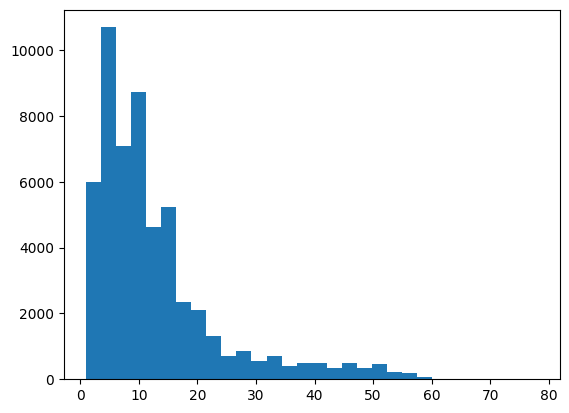

In [17]:
# 훈련 및 테스트 시퀀스의 길이 계산
sequence_lengths = [len(s) for s in train_sequences] + [len(s) for s in test_sequences]

# 히스토그램으로 시퀀스 길이 분포 시각화
plt.hist(sequence_lengths, bins=30);

In [18]:
# 최대 시퀀스 길이 설정
max_length = 15

# 훈련 시퀀스 패딩
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')

# 테스트 시퀀스 패딩
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

# 패딩된 시퀀스의 형태와 첫 번째 시퀀스 출력
print(train_padded.shape)
print(train_padded[0])
print(test_padded.shape)
print(test_padded[0])

(49571, 15)
[   90  1370    13  1554    80   520  8870 14637    29   250     5  3884
    16   430    62]
(4951, 15)
[1683    7  460 1491  106  346   37 2485  344  760  206  650   96  270
    0]


### sequence 를 다시 문장으로 역변환

In [19]:
# 패딩된 시퀀스를 원래 문장으로 디코딩하는 함수
def decode_sentence(sequence):
    return ' '.join([tokenizer.index_word.get(i, '?') for i in sequence])

# 첫 번째 패딩된 훈련 시퀀스 디코딩 및 출력
print(decode_sentence(train_padded[4]))
print()

# 원래 첫 번째 훈련 문장 출력
print(train_sentences[4])

우리나라 용가리 가 배다 더 자다 만들다 이렇다 류 영화 도 개봉 을 하나 보다

['우리나라', '용가리', '가', '배다', '더', '자다', '만들다', '이렇다', '류', '영화', '도', '개봉', '을', '하나', '보다']


In [20]:
# 시퀀셜 모델 정의
model = Sequential([
    Embedding(VOCAB_SIZE+1, 64),    # 어휘 사전 크기 + 1과 임베딩 차원을 설정
    Bidirectional(LSTM(64)),                   # 양방향 LSTM 레이어 추가
    Dense(32, activation='relu'),              # 완전 연결 레이어 추가
    Dense(1, activation='sigmoid')          # 이진 분류를 위한 출력 레이어 추가
])


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 64)          1280064   
                                                                 
 bidirectional (Bidirection  (None, 128)               66048     
 al)                                                             
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1350273 (5.15 MB)
Trainable params: 1350273 (5.15 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
num_epochs = 30
history = model.fit(train_padded, train_labels, epochs=num_epochs, batch_size=128,
                    validation_data=(test_padded, test_labels), verbose=1)

Epoch 1/30
388/388 [==============================] - 33s 64ms/step - loss: 0.4543 - accuracy: 0.7769 - val_loss: 0.4027 - val_accuracy: 0.8178
Epoch 2/30
388/388 [==============================] - 6s 15ms/step - loss: 0.3292 - accuracy: 0.8567 - val_loss: 0.3974 - val_accuracy: 0.8170
Epoch 3/30
388/388 [==============================] - 7s 17ms/step - loss: 0.2701 - accuracy: 0.8858 - val_loss: 0.4487 - val_accuracy: 0.8176
Epoch 4/30
388/388 [==============================] - 4s 11ms/step - loss: 0.2198 - accuracy: 0.9087 - val_loss: 0.5164 - val_accuracy: 0.8132
Epoch 5/30
388/388 [==============================] - 4s 10ms/step - loss: 0.1829 - accuracy: 0.9234 - val_loss: 0.5514 - val_accuracy: 0.8134
Epoch 6/30
388/388 [==============================] - 5s 14ms/step - loss: 0.1558 - accuracy: 0.9364 - val_loss: 0.5916 - val_accuracy: 0.8059
Epoch 7/30
388/388 [==============================] - 3s 9ms/step - loss: 0.1337 - accuracy: 0.9462 - val_loss: 0.6965 - val_accuracy: 0.8045

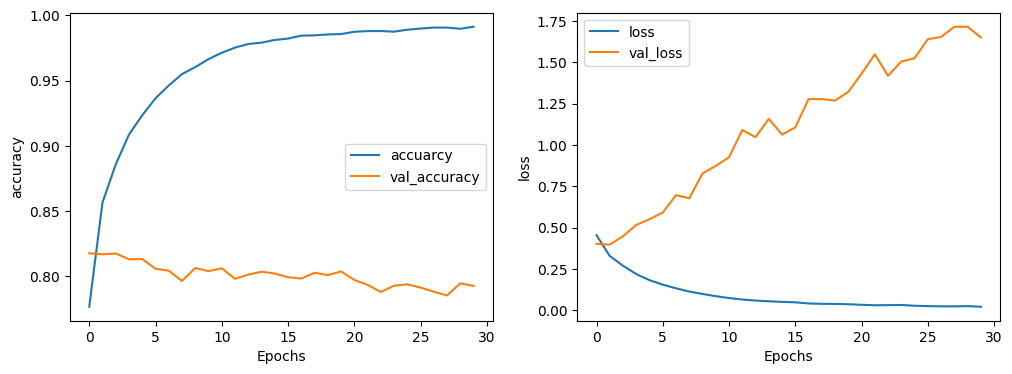

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('Epochs')
ax1.set_ylabel('accuracy')
ax1.legend(['accuarcy', 'val_accuracy'])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('Epochs')
ax2.set_ylabel('loss')
ax2.legend(['loss', 'val_loss'])
plt.show()

In [23]:
test_data.head()

,id,document,label
26247,5933705,크리스마스에 어울리는 시원한 액션. 긴장감과 박진감 넘치는 전개 엄청난 마지막부분,1
35067,5092284,또 봐도 재밌네요 ㅋ2편은 평점이거지네요;;,1
34590,4501201,완전유치뽕짝저질삼류영화..티비편이 훨씬낫다...,0
16668,8848074,이건 보는 영화가 아니다.,0
12196,178689,오랜만에 접한 수작...30대 중반 이상분들에게 추천!,1


In [24]:
sample_texts = ['이 영화는 정말 짜증나서 못 보겠다',
                           '오랜만에 접한 수작']
for sample_text in sample_texts:
    sample_seq = tokenizer.texts_to_sequences([sample_text])
    sample_padded = pad_sequences(sample_seq, maxlen=max_length, padding='post')
    prediction = model.predict(sample_padded, verbose=0)
    if prediction > 0.5:
        print('positive')
    else:
        print('negative')

negative
positive


## Embedding Layer 시각화

- Embedding projector https://projector.tensorflow.org/  를 이용하여 word embedding 시각화

In [25]:
model.layers

In [26]:
# 모델의 첫 번째 레이어(Embedding 레이어) 추출
e = model.layers[0]

# Embedding 레이어의 가중치 추출
weights = e.get_weights()[0]

# 가중치의 형태 출력
print(weights.shape)

(20001, 64)


### embedding layer 의 weight 를 disk 에 write. Embedding projector 사용을 위해 embedding vector file 과 단어가 들어 있는 meta data file 로 구분하여 upload.

In [27]:
# 임베딩 벡터와 메타데이터를 파일로 저장
out_v = open('vects.tsv', 'w', encoding='utf-8')
out_m = open('meta.tsv', 'w', encoding='utf-8')

# 가중치 배열에서 임베딩 벡터와 해당 단어 추출 및 파일에 저장
for i in range(1, 1000):
    word = tokenizer.index_word.get(i, '?')  # 인덱스에 해당하는 단어
    embeddings = weights[i]                       # 해당 단어의 임베딩 벡터
    out_m.write(word + '\n')                        # 메타데이터 파일에 단어 저장
    out_v.write('\t'.join([str(x) for x in embeddings]) + '\n')    # 임베딩 벡터 파일에 저장

# 파일 닫기
out_v.close()
out_m.close()

## Embedding 결과 확인

[Embedding Projector](https://projector.tensorflow.org) 에 접속하여 embedding 의 품질 확인

Google Colab 의 경우 local PC 로 download 받아 Embedding Projector 에 upload